In [5]:
import pandas as pd

archivo = 'temperaturas.csv' # O usa pd.read_clipboard() si prefieres el portapapeles

# Usamos header=1 para saltarnos la fila de categorías y usar la de High/Avg/Low
df = pd.read_csv(archivo, sep='\t', header=1)

# Mostramos las primeras filas y los nombres de las columnas resultantes
print(df.head())
print("\nColumnas detectadas:")
print(df.columns)

import numpy as np
import pandas as pd

# 1. Creamos una copia para no alterar el DataFrame original
df_clean = df.copy()

# 2. Limpiamos las columnas que tienen texto/unidades (excluyendo 'Date')
cols_to_clean = [col for col in df_clean.columns if col != 'Date']

for col in cols_to_clean:
  df_clean[col] = (
      df_clean[col]
      .astype(str)
      .str.replace('°F', '', regex=False)
      .str.replace('%', '', regex=False)
      .str.replace('mph', '', regex=False)
      .str.replace('in', '', regex=False)
      .str.strip()
      .astype(float)  # Convertimos a tipo numérico
  )

# 3. Convertir a Matriz de NumPy (excluyendo la columna de fechas)
matriz = df_clean.drop(columns=['Date']).to_numpy()

print('Tipo de dato:', type(matriz))
print('Forma de la matriz (Filas, Columnas):', matriz.shape)
print(matriz)

       Date     High      Avg      Low   High.1    Avg.1     Low.1 High.2  \
0  7/1/2026  14.7 °F  10.9 °F   5.4 °F   9.7 °F   4.2 °F  -13.4 °F   92 %   
1  7/2/2026  27.1 °F  17.2 °F  11.3 °F  16.9 °F   9.1 °F   -4.4 °F   97 %   
2  7/3/2026  25.5 °F  19.4 °F  15.6 °F  25.2 °F  18.0 °F   14.0 °F   99 %   
3  7/4/2026  32.7 °F  27.1 °F  23.5 °F  22.6 °F  13.5 °F    0.0 °F   83 %   
4  7/5/2026  36.9 °F  29.9 °F  23.7 °F  23.4 °F  16.4 °F   10.2 °F   72 %   

  Avg.2 Low.2    High.3     Avg.3    Low.3    High.4     Low.4      Sum  
0  75 %  31 %  38.9 mph  11.7 mph  2.5 mph  30.33 in  30.20 in  0.00 in  
1  73 %  31 %  34.9 mph  12.5 mph  1.3 mph  30.31 in  30.17 in  0.00 in  
2  94 %  68 %  23.9 mph   2.8 mph  0.0 mph  30.19 in  30.02 in  0.00 in  
3  58 %  27 %  24.2 mph   6.5 mph  0.0 mph  30.12 in  30.00 in  0.00 in  
4  57 %  33 %  21.9 mph   8.8 mph  0.0 mph  30.21 in  30.11 in  0.00 in  

Columnas detectadas:
Index(['Date', 'High', 'Avg', 'Low', 'High.1', 'Avg.1', 'Low.1', 'High.

Matplotlib is building the font cache; this may take a moment.


Fechas: [Timestamp('2026-07-01 00:00:00'), Timestamp('2026-07-02 00:00:00'), Timestamp('2026-07-03 00:00:00'), Timestamp('2026-07-04 00:00:00'), Timestamp('2026-07-05 00:00:00'), Timestamp('2026-07-06 00:00:00'), Timestamp('2026-07-07 00:00:00'), Timestamp('2026-07-08 00:00:00'), Timestamp('2026-07-09 00:00:00'), Timestamp('2026-07-10 00:00:00'), Timestamp('2026-07-11 00:00:00'), Timestamp('2026-07-12 00:00:00'), Timestamp('2026-07-13 00:00:00'), Timestamp('2026-07-14 00:00:00'), Timestamp('2026-07-15 00:00:00'), Timestamp('2026-07-16 00:00:00'), Timestamp('2026-07-17 00:00:00'), Timestamp('2026-07-18 00:00:00'), Timestamp('2026-07-19 00:00:00'), Timestamp('2026-07-20 00:00:00'), Timestamp('2026-07-21 00:00:00'), Timestamp('2026-07-22 00:00:00'), Timestamp('2026-07-23 00:00:00'), Timestamp('2026-07-24 00:00:00'), Timestamp('2026-07-25 00:00:00'), Timestamp('2026-07-26 00:00:00'), Timestamp('2026-07-27 00:00:00'), Timestamp('2026-07-28 00:00:00'), Timestamp('2026-07-29 00:00:00'), Times

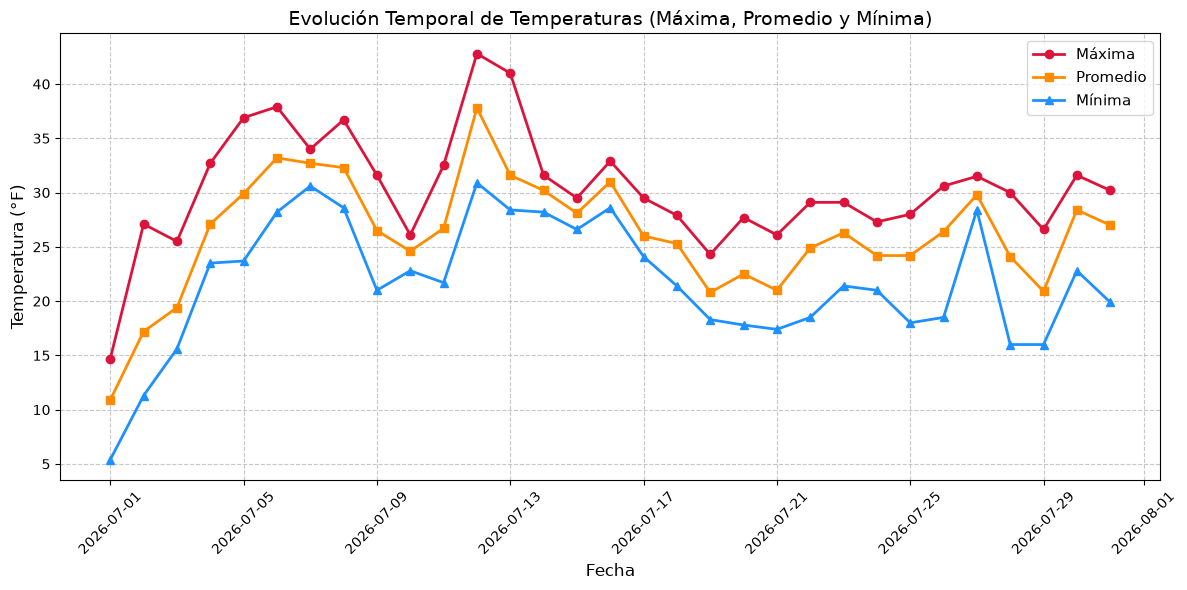

In [10]:
import matplotlib.pyplot as plt
import pandas as pd

# 1. Obtener la lista de fechas y las 3 temperaturas desde la matriz y el DataFrame
fechas = pd.to_datetime(df['Date'])

# De acuerdo al orden de tus columnas en la matriz limpia (sin 'Date'):
# Columna 0 -> High (Máxima)
# Columna 1 -> Avg (Promedio)
# Columna 2 -> Low (Mínima)
temp_max = matriz[:, 0]
temp_avg = matriz[:, 1]
temp_min = matriz[:, 2]

# Mostrar las listas obtenidas (opcional para verificar)
print('Fechas:', fechas.tolist())
print('Temperaturas Máximas:', temp_max.tolist())
print('Temperaturas Promedio:', temp_avg.tolist())
print('Temperaturas Mínimas:', temp_min.tolist())

# 2. Graficar las 3 temperaturas en un mismo gráfico
plt.figure(figsize=(12, 6))
plt.plot(
    fechas, temp_max, marker='o', color='crimson', linewidth=2, label='Máxima'
)
plt.plot(
    fechas,
    temp_avg,
    marker='s',
    color='darkorange',
    linewidth=2,
    label='Promedio',
)
plt.plot(
    fechas, temp_min, marker='^', color='dodgerblue', linewidth=2, label='Mínima'
)

# Estética del gráfico
plt.title(
    'Evolución Temporal de Temperaturas (Máxima, Promedio y Mínima)',
    fontsize=14,
)
plt.xlabel('Fecha', fontsize=12)
plt.ylabel('Temperatura (°F)', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend(fontsize=11)
plt.xticks(rotation=45)
plt.tight_layout()

# Mostrar la visualización
plt.show()

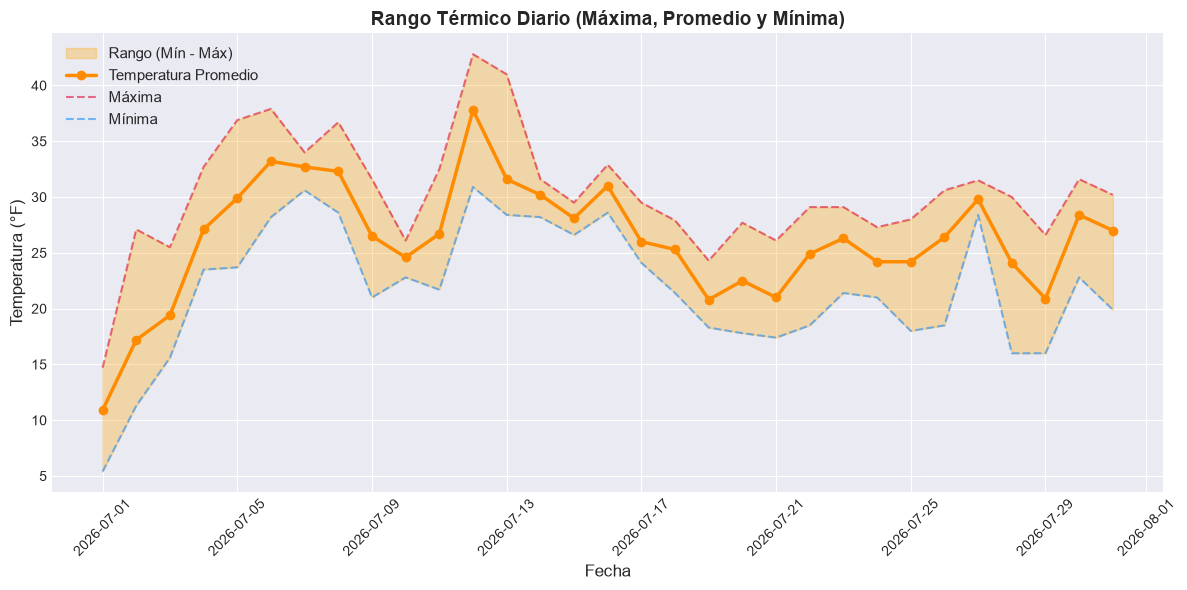

In [12]:
import matplotlib.pyplot as plt
import pandas as pd

# 1. Aplicar el estilo Seaborn (en versiones modernas de matplotlib se usa este formato)
plt.style.use('seaborn-v0_8-darkgrid')

# 2. Configurar el tamaño de la figura
plt.figure(figsize=(12, 6))

# 3. Rellenar el área entre la temperatura mínima y la máxima
plt.fill_between(
    fechas,
    temp_min,
    temp_max,
    color='orange',
    alpha=0.3,
    label='Rango (Mín - Máx)',
    zorder=2,
)

# 4. Graficar la línea de temperatura promedio por encima
plt.plot(
    fechas,
    temp_avg,
    color='darkorange',
    linewidth=2.5,
    marker='o',
    label='Temperatura Promedio',
    zorder=3,
)

# Opcional: Agregar líneas sutiles para los bordes máximo y mínimo
plt.plot(
    fechas,
    temp_max,
    color='crimson',
    linestyle='--',
    alpha=0.6,
    label='Máxima',
    zorder=2,
)
plt.plot(
    fechas,
    temp_min,
    color='dodgerblue',
    linestyle='--',
    alpha=0.6,
    label='Mínima',
    zorder=2,
)

# 5. Detalles estéticos del gráfico
plt.title(
    'Rango Térmico Diario (Máxima, Promedio y Mínima)',
    fontsize=14,
    fontweight='bold',
)
plt.xlabel('Fecha', fontsize=12)
plt.ylabel('Temperatura (°F)', fontsize=12)
plt.legend(fontsize=11, loc='upper left')
plt.xticks(rotation=45)
plt.tight_layout()

# Mostrar el gráfico resultante
plt.show()